In [1]:
import sys

from pathlib import Path
import h5py
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

from lab_tools.io import read_keysight_h5, read_segment_time_tags

In [2]:
# data_file_ch1 = Path("data/pmtch1.h5")
# data_file_ch2 = Path("data/pmtch2.h5")

data_file_ch1 = Path("data/pmtch1-2.h5")
data_file_ch2 = Path("data/pmtch2-2.h5")

In [3]:
time1, voltage1, metadata1 = read_keysight_h5(
    data_file_ch1,
    channel="Channel 1",
    segment_numbers=None, # if None, will read all segments
)

print("time shape:   ", time1.shape)
print("voltage shape:", voltage1.shape)
print("segments:     ", metadata1["segment_numbers"])
print("frame:        ", metadata1["frame"])
print("XInc:         ", metadata1["channel_attrs"]["XInc"]) # time step between samples
print("Y units:      ", metadata1["channel_attrs"]["YUnits"]) # voltage units 

time shape:    (6401,)
voltage shape: (2048, 6401)
segments:      [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 2

In [4]:
time2, voltage2, metadata2 = read_keysight_h5(
    data_file_ch2,
    channel="Channel 2",
    segment_numbers=None, # if None, will read all segments
)

print("time shape:   ", time2.shape)
print("voltage shape:", voltage2.shape)
print("segments:     ", metadata2["segment_numbers"])
print("frame:        ", metadata2["frame"])
print("XInc:         ", metadata2["channel_attrs"]["XInc"]) # time step between samples
print("Y units:      ", metadata2["channel_attrs"]["YUnits"]) # voltage units 

time shape:    (6401,)
voltage shape: (2048, 6401)
segments:      [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 2

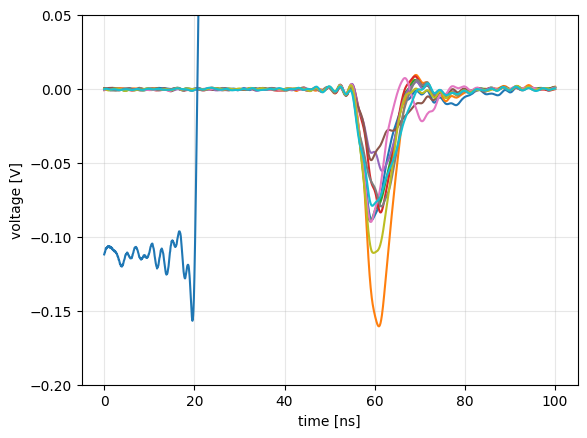

In [11]:
for i in range(0, 10):
    plt.plot(time1 * 1e9, voltage1[i])
plt.plot(time2 * 1e9, voltage2[0], label=f"Channel 2")
plt.xlabel("time [ns]")
plt.ylabel("voltage [V]")
plt.grid(True, alpha=0.3)
plt.ylim(-0.2, 0.05)
plt.show();

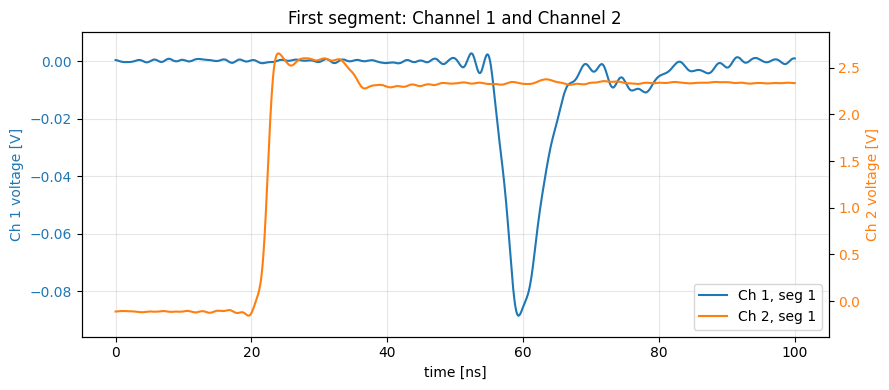

In [13]:
seg_idx = 0  # first segment in the voltage arrays
seg_ch1 = metadata1["segment_numbers"][seg_idx]
seg_ch2 = metadata2["segment_numbers"][seg_idx]

def padded_ylim(y, pad=0.08):
    y_min = np.nanmin(y)
    y_max = np.nanmax(y)
    span = y_max - y_min
    if span == 0:
        span = max(abs(y_max), 1.0)
    return y_min - pad * span, y_max + pad * span

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

color_ch1 = "tab:blue"
color_ch2 = "tab:orange"

line1, = ax1.plot(time1 * 1e9, voltage1[seg_idx], color=color_ch1, label=f"Ch 1, seg {seg_ch1}")
line2, = ax2.plot(time2 * 1e9, voltage2[seg_idx], color=color_ch2, label=f"Ch 2, seg {seg_ch2}")

ax1.set_ylim(*padded_ylim(voltage1[seg_idx]))
ax2.set_ylim(*padded_ylim(voltage2[seg_idx]))
ax1.set_xlabel("time [ns]")
ax1.set_ylabel("Ch 1 voltage [V]", color=color_ch1)
ax2.set_ylabel("Ch 2 voltage [V]", color=color_ch2)
ax1.tick_params(axis="y", labelcolor=color_ch1)
ax2.tick_params(axis="y", labelcolor=color_ch2)
ax1.grid(True, alpha=0.3)

lines = [line1, line2]
ax1.legend(lines, [line.get_label() for line in lines], loc="lower right")
ax1.set_title("First segment: Channel 1 and Channel 2")
fig.tight_layout()
plt.show();


In [14]:
trigger_fraction = 0.50
pulse_fraction = 0.50
trigger_polarity = 1  # LED pulser trigger; use -1 if the trigger pulse is negative
pulse_polarity = None  # auto-detect PMT pulse polarity; set to -1 or +1 if needed

def leading_edge_time(t, y, fraction=0.5, polarity=None, baseline_fraction=0.10):
    baseline_n = max(1, int(baseline_fraction * len(y)))
    baseline = np.nanmedian(y[:baseline_n])
    y0 = y - baseline

    if polarity is None:
        polarity = 1 if np.nanmax(y0) >= abs(np.nanmin(y0)) else -1

    signed_y = polarity * y0
    peak_idx = np.nanargmax(signed_y)
    amplitude = signed_y[peak_idx]
    if not np.isfinite(amplitude) or amplitude <= 0:
        return np.nan

    threshold = fraction * amplitude
    crossing_indices = np.flatnonzero(signed_y[: peak_idx + 1] >= threshold)
    if len(crossing_indices) == 0:
        return np.nan

    i = crossing_indices[0]
    if i == 0:
        return t[0]

    y_before, y_after = signed_y[i - 1], signed_y[i]
    t_before, t_after = t[i - 1], t[i]
    if y_after == y_before:
        return t_after

    return t_before + (threshold - y_before) * (t_after - t_before) / (y_after - y_before)

segments1 = np.array(metadata1["segment_numbers"])
segments2 = np.array(metadata2["segment_numbers"])
idx1_by_segment = {segment: i for i, segment in enumerate(segments1)}
idx2_by_segment = {segment: i for i, segment in enumerate(segments2)}
common_segments = np.array([segment for segment in segments1 if segment in idx2_by_segment])

pulse_times = np.array([
    leading_edge_time(time1, voltage1[idx1_by_segment[segment]], pulse_fraction, pulse_polarity)
    for segment in common_segments
])
trigger_times = np.array([
    leading_edge_time(time2, voltage2[idx2_by_segment[segment]], trigger_fraction, trigger_polarity)
    for segment in common_segments
])

delay_ns = (pulse_times - trigger_times) * 1e9
valid_delay = np.isfinite(delay_ns)

print(f"Measured {valid_delay.sum()} / {len(common_segments)} common segments")
print(f"median delay: {np.nanmedian(delay_ns):.3f} ns")
print(f"mean delay:   {np.nanmean(delay_ns):.3f} ns")
print(f"std delay:    {np.nanstd(delay_ns):.3f} ns")


Measured 2048 / 2048 common segments
median delay: 34.953 ns
mean delay:   34.967 ns
std delay:    0.613 ns


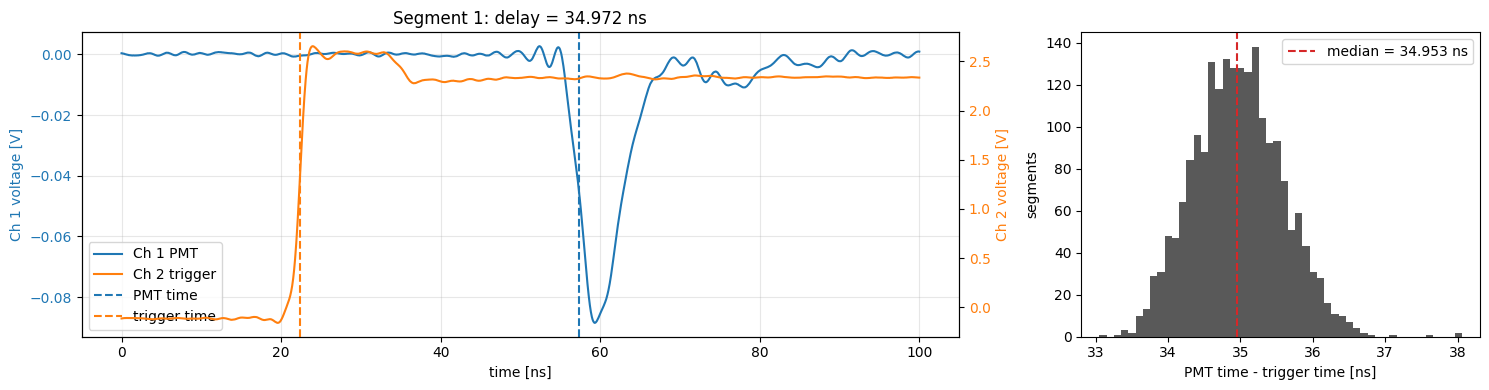

In [ ]:
plot_idx = 0
segment = common_segments[plot_idx]
i1 = idx1_by_segment[segment]
i2 = idx2_by_segment[segment]

fig, (ax_wave, ax_hist) = plt.subplots(
    1,
    2,
    figsize=(15, 4),
    gridspec_kw={"width_ratios": [2.2, 1]},
)
ax_trig = ax_wave.twinx()

line_pulse, = ax_wave.plot(time1 * 1e9, voltage1[i1], color="tab:blue", label="Ch 1 PMT")
line_trigger, = ax_trig.plot(time2 * 1e9, voltage2[i2], color="tab:orange", label="Ch 2 trigger")
mark_pulse = ax_wave.axvline(pulse_times[plot_idx] * 1e9, color="tab:blue", linestyle="--", label="PMT time")
mark_trigger = ax_trig.axvline(trigger_times[plot_idx] * 1e9, color="tab:orange", linestyle="--", label="trigger time")

ax_wave.set_xlabel("time [ns]")
ax_wave.set_ylabel("Ch 1 voltage [V]", color="tab:blue")
ax_trig.set_ylabel("Ch 2 voltage [V]", color="tab:orange")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")
ax_trig.tick_params(axis="y", labelcolor="tab:orange")
ax_wave.grid(True, alpha=0.3)
ax_wave.set_title(f"Segment {segment}: delay = {delay_ns[plot_idx]:.3f} ns")

handles = [line_pulse, line_trigger, mark_pulse, mark_trigger]
ax_wave.legend(handles, [handle.get_label() for handle in handles], loc="best")

median_delay_ns = np.nanmedian(delay_ns)
ax_hist.hist(delay_ns[valid_delay], bins=50, color="0.35")
ax_hist.axvline(median_delay_ns, color="tab:red", linestyle="--", label=f"median = {median_delay_ns:.3f} ns")

ax_hist.set_xlabel("PMT time - trigger time [ns]")
ax_hist.set_ylabel("segments")
ax_hist.legend()

fig.tight_layout()
plt.show();


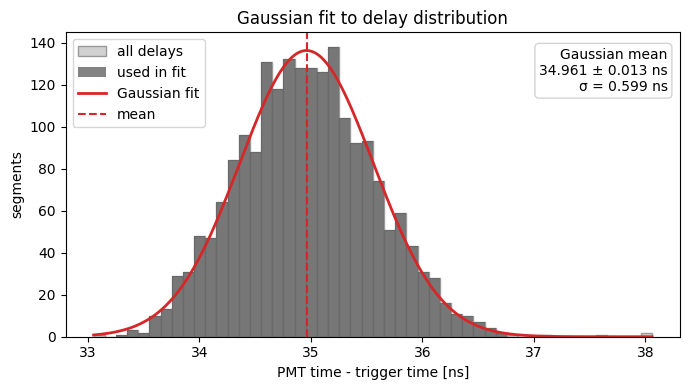

Gaussian mean delay: 34.961 ± 0.013 ns
Gaussian sigma:      0.599 ns
Fit used:            2042 / 2048 delays


In [16]:
fit_window_sigma = 3.0
all_delays_ns = delay_ns[valid_delay]
all_delays_ns = all_delays_ns[np.isfinite(all_delays_ns)]

robust_center_ns = np.median(all_delays_ns)
robust_sigma_ns = 1.4826 * np.median(np.abs(all_delays_ns - robust_center_ns))
if np.isfinite(robust_sigma_ns) and robust_sigma_ns > 0:
    fit_mask = np.abs(all_delays_ns - robust_center_ns) <= fit_window_sigma * robust_sigma_ns
else:
    fit_mask = np.ones_like(all_delays_ns, dtype=bool)

fit_delays_ns = all_delays_ns[fit_mask]
if len(fit_delays_ns) < 2:
    raise ValueError("Need at least two valid delays for a Gaussian fit")

gauss_mean_ns = np.mean(fit_delays_ns)
gauss_sigma_ns = np.std(fit_delays_ns, ddof=1)
gauss_mean_err_ns = gauss_sigma_ns / np.sqrt(len(fit_delays_ns))

fig, ax = plt.subplots(figsize=(7, 4))
counts, edges, _ = ax.hist(all_delays_ns, bins=50, color="0.82", edgecolor="0.6", label="all delays")
ax.hist(fit_delays_ns, bins=edges, color="0.35", alpha=0.75, label="used in fit")

bin_width_ns = edges[1] - edges[0]
x_fit = np.linspace(edges[0], edges[-1], 500)
gauss_counts = (
    len(fit_delays_ns)
    * bin_width_ns
    / (gauss_sigma_ns * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x_fit - gauss_mean_ns) / gauss_sigma_ns) ** 2)
)

ax.plot(x_fit, gauss_counts, color="tab:red", lw=2, label="Gaussian fit")
ax.axvline(gauss_mean_ns, color="tab:red", linestyle="--", label=f"mean")
ax.text(
    0.98,
    0.95,
    f"Gaussian mean\n{gauss_mean_ns:.3f} ± {gauss_mean_err_ns:.3f} ns\nσ = {gauss_sigma_ns:.3f} ns",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
ax.set_xlabel("PMT time - trigger time [ns]")
ax.set_ylabel("segments")
ax.set_title("Gaussian fit to delay distribution")
ax.legend()
fig.tight_layout()
plt.show();

print(f"Gaussian mean delay: {gauss_mean_ns:.3f} ± {gauss_mean_err_ns:.3f} ns")
print(f"Gaussian sigma:      {gauss_sigma_ns:.3f} ns")
print(f"Fit used:            {len(fit_delays_ns)} / {len(all_delays_ns)} delays")


In [10]:
# Gaussian mean delay: 34.353 ± 0.021 ns
# Gaussian sigma:      0.661 ns
# Fit used:            1020 / 1024 delays